# 05 – Stationarity Checks

**Purpose:** Verify whether the total daily sales series is stationary before applying AR/MA/ARIMA models.  
**Tests applied:**
- ADF (Augmented Dickey-Fuller) – null = unit root (non-stationary)
- KPSS (Kwiatkowski-Phillips-Schmidt-Shin) – null = stationary
- ACF / PACF plots
- Classical seasonal decomposition
- Differencing (d=1, d=2) + recheck if needed

**Decision rule (ADF + KPSS combined):**

| ADF | KPSS | Conclusion |
|-----|------|------------|
| Reject H₀ | Fail to reject H₀ | Stationary ✅ |
| Fail to reject H₀ | Reject H₀ | Non-stationary ❌ |
| Reject H₀ | Reject H₀ | Trend-stationary ⚠️ |
| Fail to reject H₀ | Fail to reject H₀ | Difference-stationary ⚠️ |

## 0. Setup

In [ ]:
import sys
from pathlib import Path

_here = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [_here] + list(_here.parents) if (p / 'config.py').exists()),
    _here
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import PROJECT_ROOT, DATA_DIR, RAW_DIR, PROCESSED_DIR, SPLITS_DIR

MODELS_DIR    = PROJECT_ROOT / 'models'
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Plotting defaults ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

DATA_DIR = PROCESSED_DIR
TRAIN_FILE = PROCESSED_DIR / 'train_cleaned.csv'
ALPHA = 0.05        # significance level for all tests
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Aggregate to Daily Total Sales

In [2]:
df = pd.read_csv(TRAIN_FILE, parse_dates=['date'])
print(f'Raw shape: {df.shape}')
print(f'Date range: {df["date"].min().date()}  →  {df["date"].max().date()}')
df.head(3)

Raw shape: (3000888, 6)
Date range: 2013-01-01  →  2017-08-15


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0


In [3]:
# Aggregate: sum all stores × families per day
daily = (
    df.groupby('date')['sales']
      .sum()
      .sort_index()
      .asfreq('D')          # enforce daily frequency (fills gaps with NaN)
)

print(f'Daily series length : {len(daily)}')
print(f'Missing dates (NaN) : {daily.isna().sum()}')

# Forward-fill any gaps (e.g. closed-store days)
daily = daily.fillna(method='ffill')
daily.name = 'total_sales'
daily.head()

Daily series length : 1688
Missing dates (NaN) : 4


date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Freq: D, Name: total_sales, dtype: float64

## 2. Visual Inspection – Raw Series

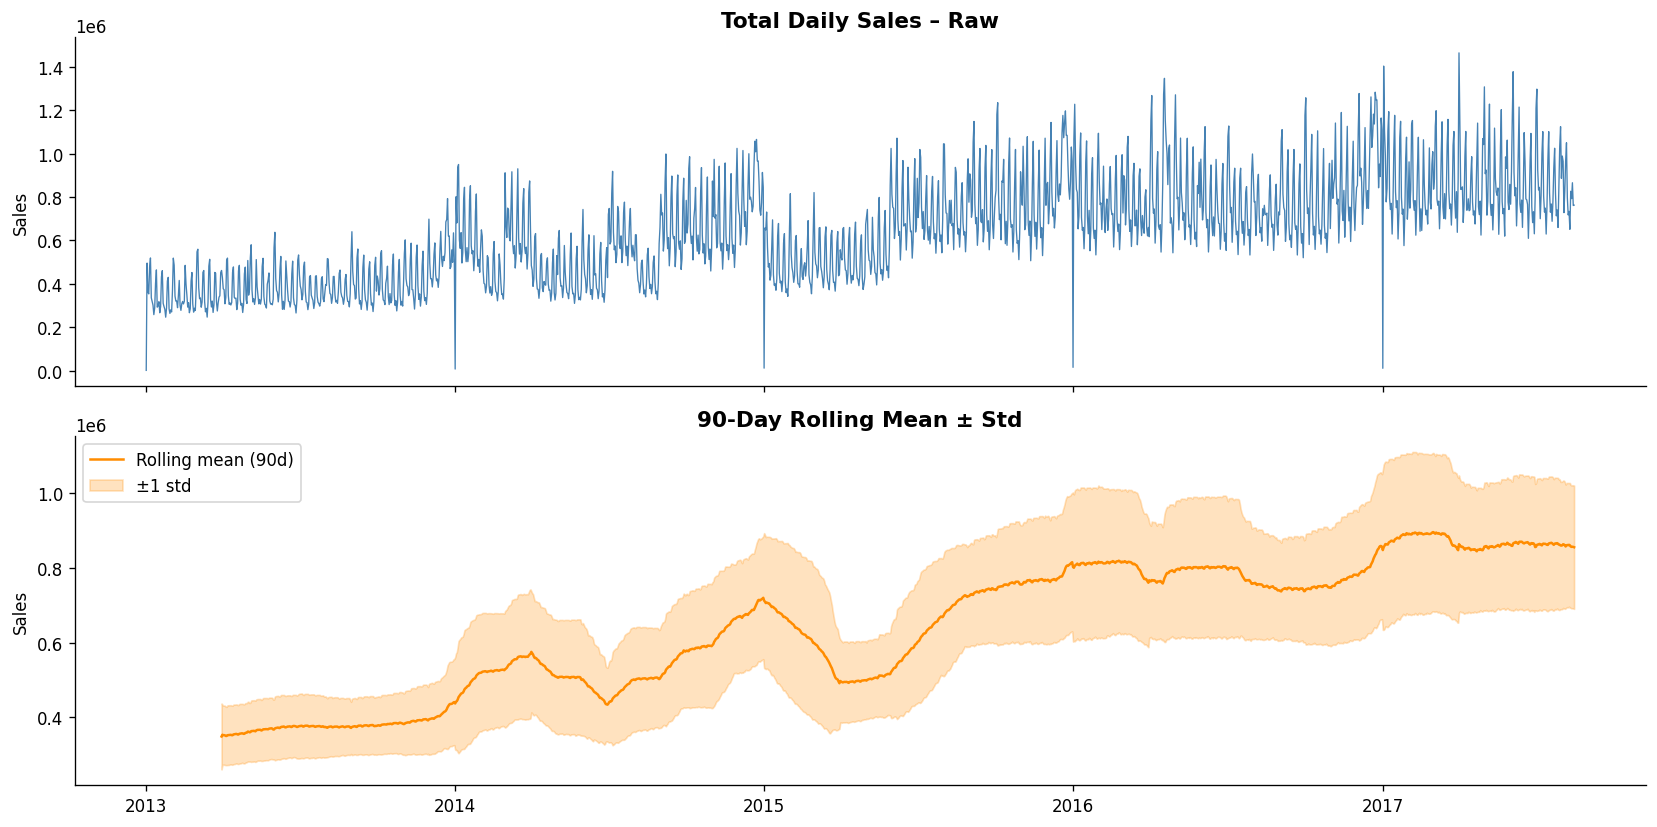

Observation: If the rolling mean drifts over time → strong sign of non-stationarity.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# — Level
axes[0].plot(daily.index, daily.values, linewidth=0.8, color='steelblue')
axes[0].set_title('Total Daily Sales – Raw', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales')

# 90-day rolling mean + std
roll = daily.rolling(window=90)
axes[1].plot(daily.index, roll.mean(), label='Rolling mean (90d)', color='darkorange')
axes[1].fill_between(
    daily.index,
    roll.mean() - roll.std(),
    roll.mean() + roll.std(),
    alpha=0.25, color='darkorange', label='±1 std'
)
axes[1].set_title('90-Day Rolling Mean ± Std', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sales')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Observation: If the rolling mean drifts over time → strong sign of non-stationarity.')

## 3. Seasonal Decomposition

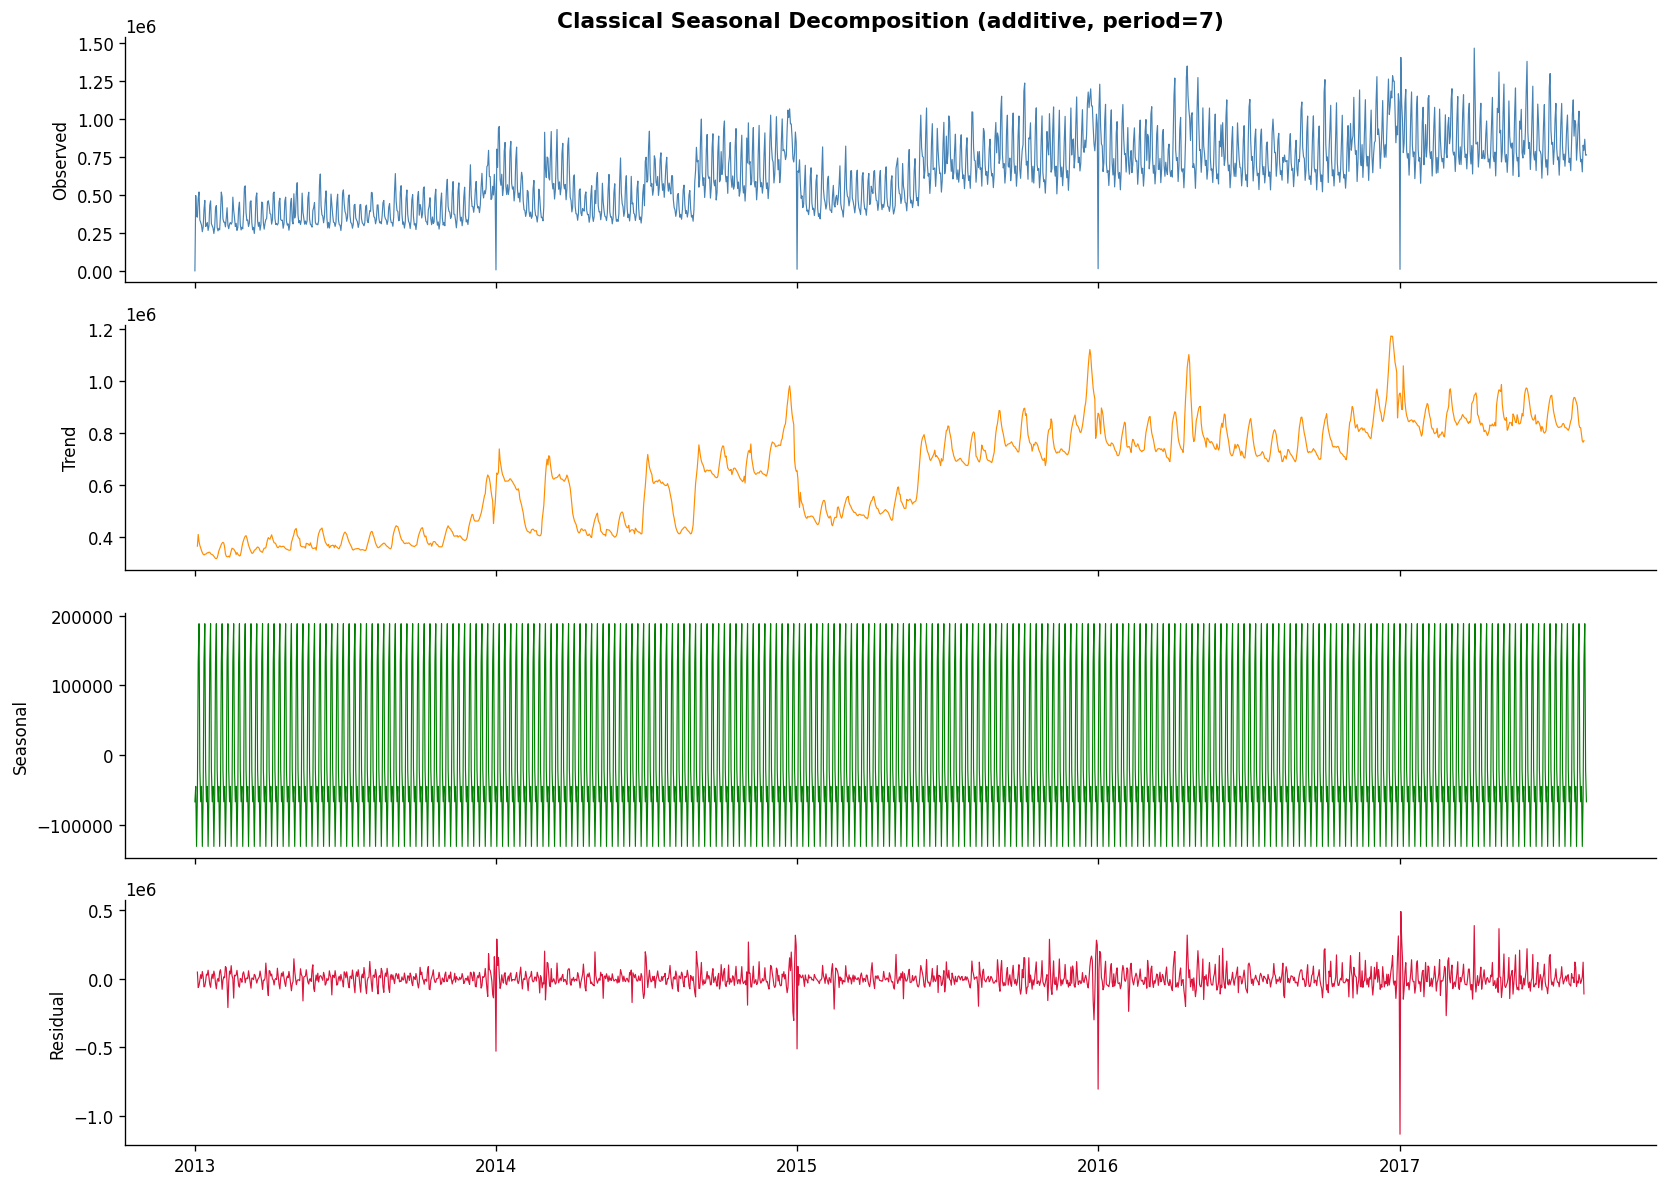

Strength of trend    : 0.866  (>0.6 = strong)
Strength of seasonality: 0.664  (>0.6 = strong)


In [5]:
# Use additive model first; switch to multiplicative if variance grows with level
decomp = seasonal_decompose(daily, model='additive', period=7)  # weekly seasonality

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
components = [
    ('Observed',   decomp.observed,   'steelblue'),
    ('Trend',      decomp.trend,      'darkorange'),
    ('Seasonal',   decomp.seasonal,   'green'),
    ('Residual',   decomp.resid,      'crimson'),
]
for ax, (label, series, color) in zip(axes, components):
    ax.plot(series.index, series.values, linewidth=0.7, color=color)
    ax.set_ylabel(label, fontsize=10)

axes[0].set_title('Classical Seasonal Decomposition (additive, period=7)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Strength of trend and seasonality (Wang et al. 2006)
var_resid = np.nanvar(decomp.resid)
strength_trend = max(0, 1 - var_resid / np.nanvar(decomp.trend + decomp.resid))
strength_season = max(0, 1 - var_resid / np.nanvar(decomp.seasonal + decomp.resid))
print(f'Strength of trend    : {strength_trend:.3f}  (>0.6 = strong)')
print(f'Strength of seasonality: {strength_season:.3f}  (>0.6 = strong)')

## 4. ACF & PACF – Original Series

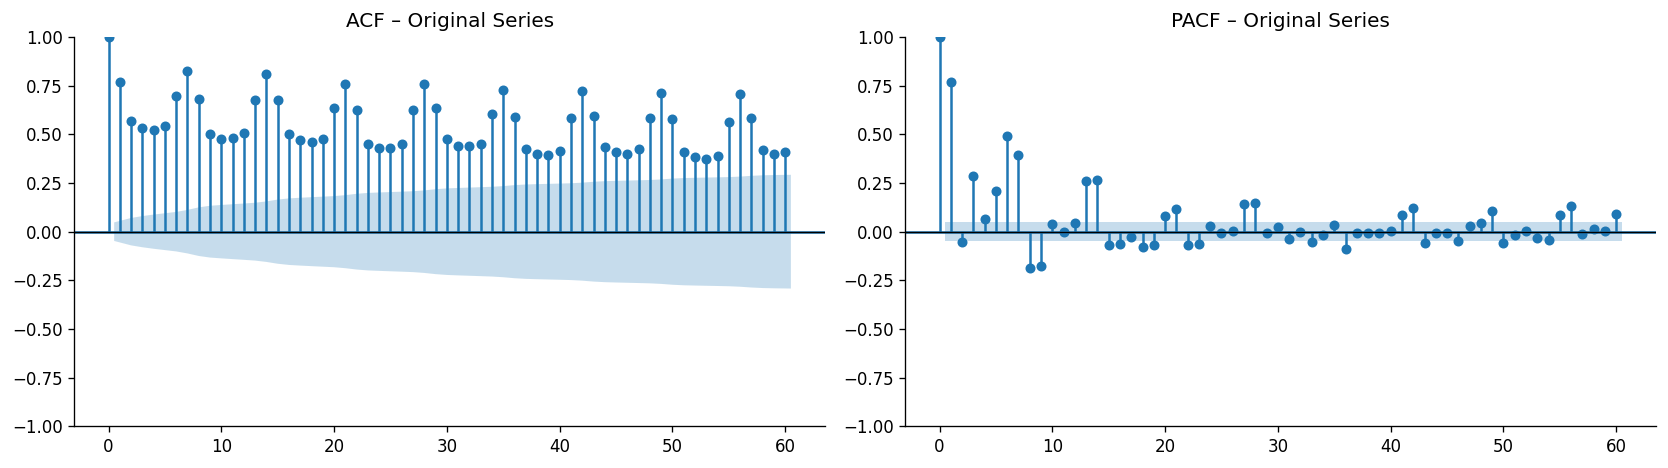


Interpretation guide:
  ACF  decays slowly → likely non-stationary (unit root or trend)
  ACF  has sharp cutoff at lag q → MA(q) process
  PACF has sharp cutoff at lag p → AR(p) process
  Spikes at lags 7, 14, 21 … → weekly seasonality



In [6]:
def plot_acf_pacf(series, lags=50, title=''):
    """Plot ACF and PACF side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(series.dropna(),  lags=lags, ax=ax1, title=f'ACF – {title}')
    plot_pacf(series.dropna(), lags=lags, ax=ax2, title=f'PACF – {title}', method='ywm')
    for ax in (ax1, ax2):
        ax.axhline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

plot_acf_pacf(daily, lags=60, title='Original Series')

print("""
Interpretation guide:
  ACF  decays slowly → likely non-stationary (unit root or trend)
  ACF  has sharp cutoff at lag q → MA(q) process
  PACF has sharp cutoff at lag p → AR(p) process
  Spikes at lags 7, 14, 21 … → weekly seasonality
""")

## 5. Formal Stationarity Tests – Original Series

In [7]:
def run_adf(series, label='Series'):
    """ADF test. H0: unit root (non-stationary)."""
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval, lags_used, nobs = result[:4]
    crit = result[4]
    reject = pval < ALPHA
    print(f'─── ADF Test: {label} ───')
    print(f'  Test statistic : {stat:.4f}')
    print(f'  p-value        : {pval:.4f}')
    print(f'  Lags used      : {lags_used}  |  n obs: {nobs}')
    for k, v in crit.items():
        print(f'  Critical ({k}) : {v:.4f}')
    if reject:
        print(f'  ✅ Reject H₀  → STATIONARY at α={ALPHA}')
    else:
        print(f'  ❌ Fail to reject H₀ → NON-STATIONARY at α={ALPHA}')
    print()
    return {'stat': stat, 'pval': pval, 'reject_h0': reject}


def run_kpss(series, label='Series', regression='c'):
    """KPSS test. H0: stationary.
    regression='c'  → level stationarity
    regression='ct' → trend stationarity
    """
    stat, pval, lags_used, crit = kpss(series.dropna(), regression=regression, nlags='auto')
    reject = pval < ALPHA
    print(f'─── KPSS Test: {label} (regression="{regression}") ───')
    print(f'  Test statistic : {stat:.4f}')
    print(f'  p-value        : {pval:.4f}')
    print(f'  Lags used      : {lags_used}')
    for k, v in crit.items():
        print(f'  Critical ({k}) : {v:.4f}')
    if reject:
        print(f'  ❌ Reject H₀  → NON-STATIONARY at α={ALPHA}')
    else:
        print(f'  ✅ Fail to reject H₀ → STATIONARY at α={ALPHA}')
    print()
    return {'stat': stat, 'pval': pval, 'reject_h0': reject}


adf_orig  = run_adf(daily,  label='Original')
kpss_orig = run_kpss(daily, label='Original', regression='c')

─── ADF Test: Original ───
  Test statistic : -2.6233
  p-value        : 0.0883
  Lags used      : 22  |  n obs: 1665
  Critical (1%) : -3.4343
  Critical (5%) : -2.8633
  Critical (10%) : -2.5677
  ❌ Fail to reject H₀ → NON-STATIONARY at α=0.05

─── KPSS Test: Original (regression="c") ───
  Test statistic : 5.7232
  p-value        : 0.0100
  Lags used      : 24
  Critical (10%) : 0.3470
  Critical (5%) : 0.4630
  Critical (2.5%) : 0.5740
  Critical (1%) : 0.7390
  ❌ Reject H₀  → NON-STATIONARY at α=0.05



C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_28680\3720366525.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags_used, crit = kpss(series.dropna(), regression=regression, nlags='auto')


In [8]:
def stationarity_verdict(adf_result, kpss_result, label='Series'):
    adf_reject  = adf_result['reject_h0']   # True → stationary signal
    kpss_reject = kpss_result['reject_h0']  # True → non-stationary signal
    print(f'═══ Combined Verdict: {label} ═══')
    if adf_reject and not kpss_reject:
        print('  → STATIONARY ✅')
    elif not adf_reject and kpss_reject:
        print('  → NON-STATIONARY ❌  (needs differencing)')
    elif adf_reject and kpss_reject:
        print('  → TREND-STATIONARY ⚠️  (remove deterministic trend)')
    else:
        print('  → DIFFERENCE-STATIONARY ⚠️  (first difference may help)')
    print()

stationarity_verdict(adf_orig, kpss_orig, label='Original Series')

═══ Combined Verdict: Original Series ═══
  → NON-STATIONARY ❌  (needs differencing)



## 6. First Differencing (d = 1)

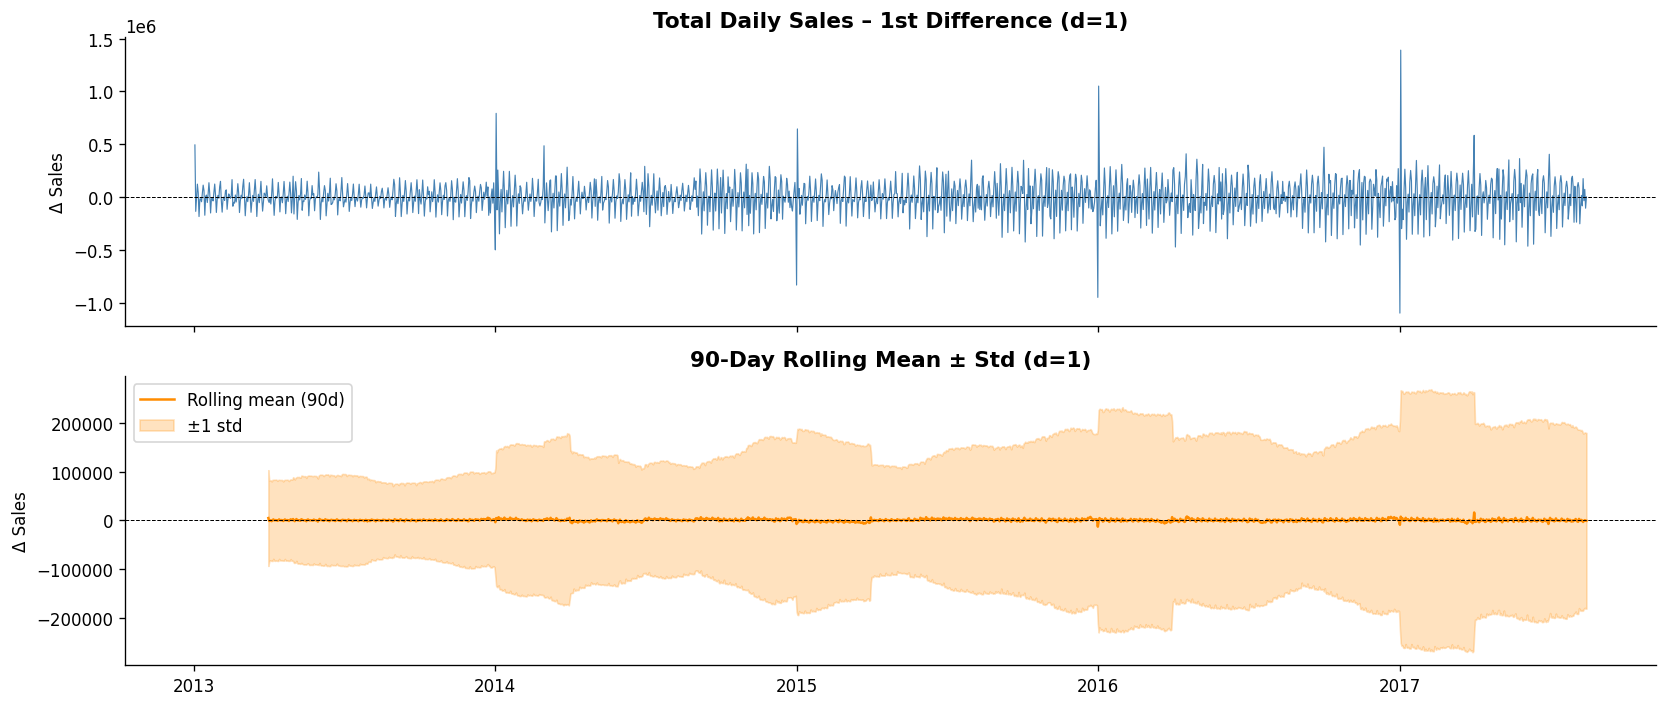

In [9]:
daily_d1 = daily.diff(1).dropna()
daily_d1.name = 'total_sales_d1'

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(daily_d1.index, daily_d1.values, linewidth=0.7, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_title('Total Daily Sales – 1st Difference (d=1)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Δ Sales')

roll1 = daily_d1.rolling(window=90)
axes[1].plot(daily_d1.index, roll1.mean(), label='Rolling mean (90d)', color='darkorange')
axes[1].fill_between(
    daily_d1.index,
    roll1.mean() - roll1.std(),
    roll1.mean() + roll1.std(),
    alpha=0.25, color='darkorange', label='±1 std'
)
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].set_title('90-Day Rolling Mean ± Std (d=1)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Δ Sales')
axes[1].legend()

plt.tight_layout()
plt.show()

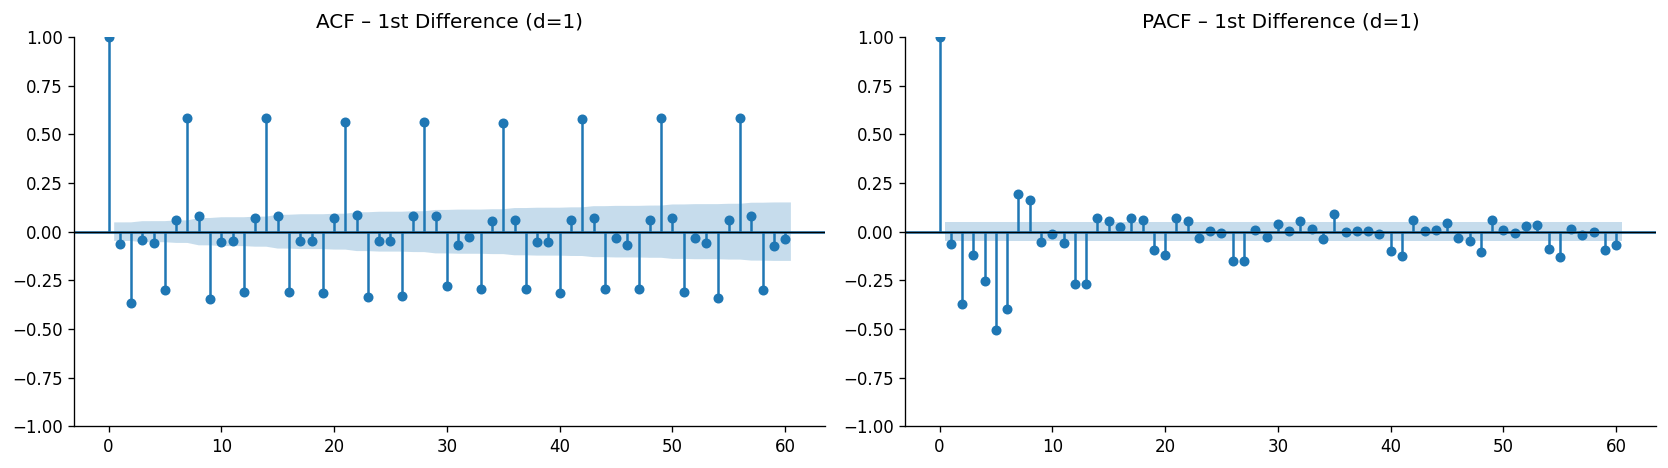

In [10]:
plot_acf_pacf(daily_d1, lags=60, title='1st Difference (d=1)')

In [11]:
adf_d1  = run_adf(daily_d1,  label='d=1')
kpss_d1 = run_kpss(daily_d1, label='d=1', regression='c')
stationarity_verdict(adf_d1, kpss_d1, label='1st Difference (d=1)')

─── ADF Test: d=1 ───
  Test statistic : -11.3511
  p-value        : 0.0000
  Lags used      : 25  |  n obs: 1661
  Critical (1%) : -3.4343
  Critical (5%) : -2.8633
  Critical (10%) : -2.5677
  ✅ Reject H₀  → STATIONARY at α=0.05

─── KPSS Test: d=1 (regression="c") ───
  Test statistic : 0.0648
  p-value        : 0.1000
  Lags used      : 54
  Critical (10%) : 0.3470
  Critical (5%) : 0.4630
  Critical (2.5%) : 0.5740
  Critical (1%) : 0.7390
  ✅ Fail to reject H₀ → STATIONARY at α=0.05

═══ Combined Verdict: 1st Difference (d=1) ═══
  → STATIONARY ✅



C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_28680\3720366525.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags_used, crit = kpss(series.dropna(), regression=regression, nlags='auto')


## 7. Second Differencing (d = 2) — if d=1 is still non-stationary

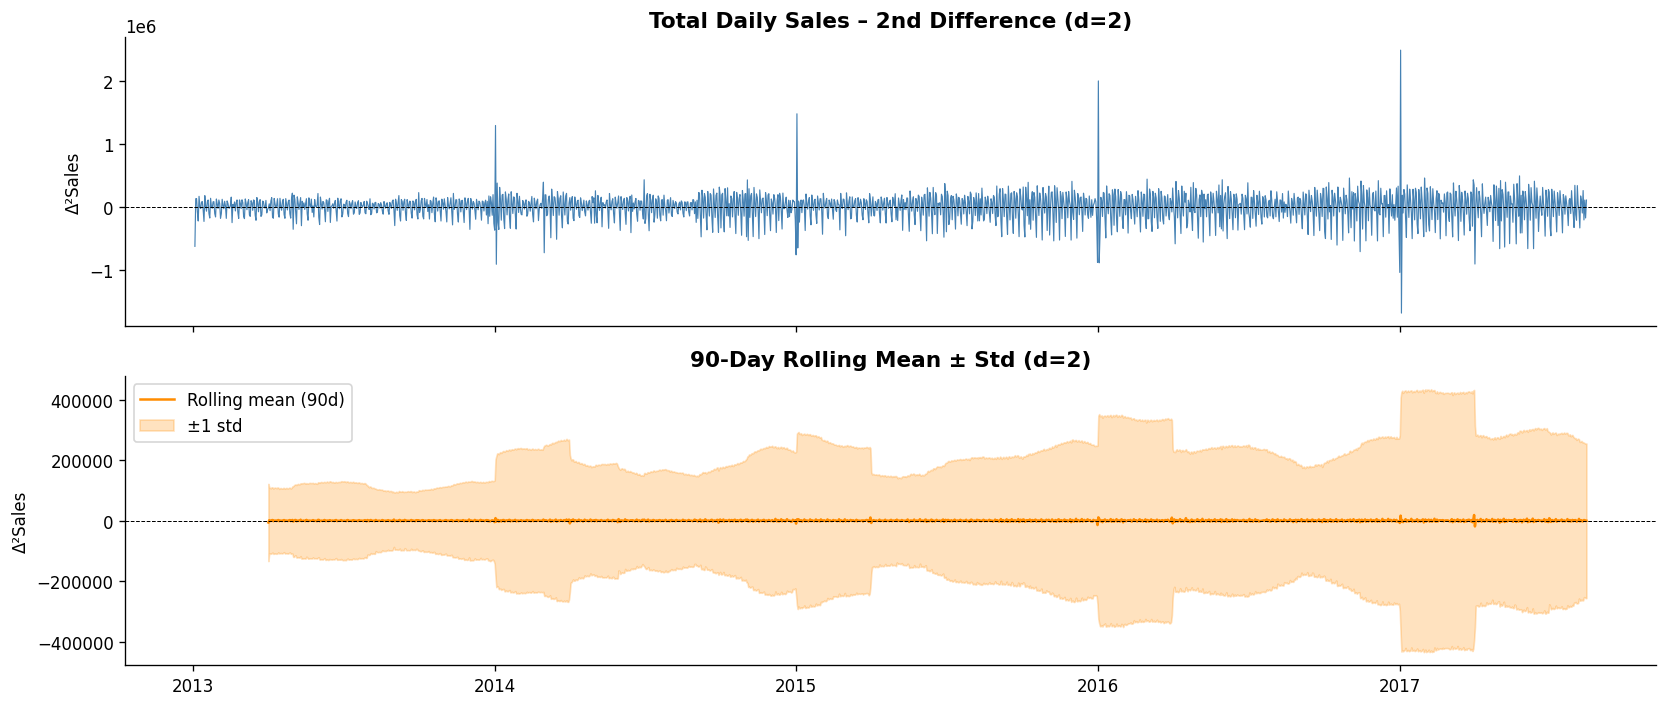

In [12]:
daily_d2 = daily.diff(1).diff(1).dropna()
daily_d2.name = 'total_sales_d2'

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(daily_d2.index, daily_d2.values, linewidth=0.7, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_title('Total Daily Sales – 2nd Difference (d=2)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Δ²Sales')

roll2 = daily_d2.rolling(window=90)
axes[1].plot(daily_d2.index, roll2.mean(), label='Rolling mean (90d)', color='darkorange')
axes[1].fill_between(
    daily_d2.index,
    roll2.mean() - roll2.std(),
    roll2.mean() + roll2.std(),
    alpha=0.25, color='darkorange', label='±1 std'
)
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].set_title('90-Day Rolling Mean ± Std (d=2)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Δ²Sales')
axes[1].legend()

plt.tight_layout()
plt.show()

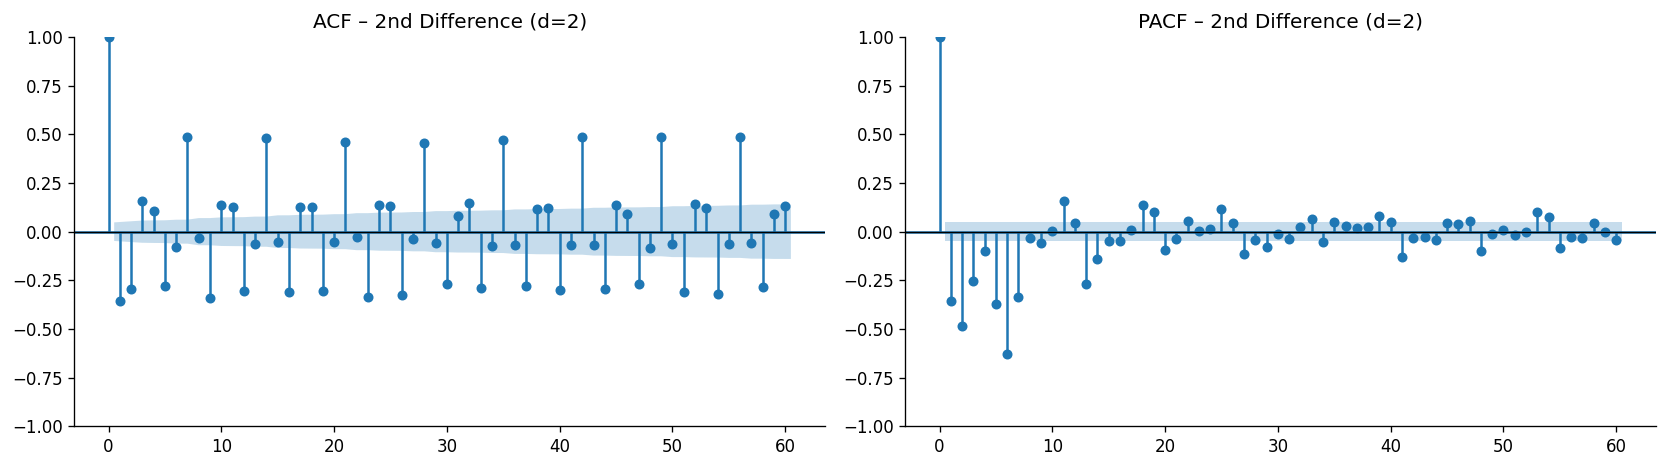

In [13]:
plot_acf_pacf(daily_d2, lags=60, title='2nd Difference (d=2)')

In [14]:
adf_d2  = run_adf(daily_d2,  label='d=2')
kpss_d2 = run_kpss(daily_d2, label='d=2', regression='c')
stationarity_verdict(adf_d2, kpss_d2, label='2nd Difference (d=2)')

─── ADF Test: d=2 ───
  Test statistic : -12.7401
  p-value        : 0.0000
  Lags used      : 25  |  n obs: 1660
  Critical (1%) : -3.4343
  Critical (5%) : -2.8633
  Critical (10%) : -2.5677
  ✅ Reject H₀  → STATIONARY at α=0.05

─── KPSS Test: d=2 (regression="c") ───
  Test statistic : 0.0493
  p-value        : 0.1000
  Lags used      : 57
  Critical (10%) : 0.3470
  Critical (5%) : 0.4630
  Critical (2.5%) : 0.5740
  Critical (1%) : 0.7390
  ✅ Fail to reject H₀ → STATIONARY at α=0.05

═══ Combined Verdict: 2nd Difference (d=2) ═══
  → STATIONARY ✅



C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_28680\3720366525.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags_used, crit = kpss(series.dropna(), regression=regression, nlags='auto')


## 8. Summary & Recommended d for ARIMA

In [15]:
summary = pd.DataFrame([
    {
        'Series'         : 'Original (d=0)',
        'ADF stat'       : round(adf_orig['stat'],  4),
        'ADF p-val'      : round(adf_orig['pval'],  4),
        'ADF Stationary' : '✅' if adf_orig['reject_h0']  else '❌',
        'KPSS stat'      : round(kpss_orig['stat'], 4),
        'KPSS p-val'     : round(kpss_orig['pval'], 4),
        'KPSS Stationary': '❌' if kpss_orig['reject_h0'] else '✅',
    },
    {
        'Series'         : '1st Diff (d=1)',
        'ADF stat'       : round(adf_d1['stat'],  4),
        'ADF p-val'      : round(adf_d1['pval'],  4),
        'ADF Stationary' : '✅' if adf_d1['reject_h0']  else '❌',
        'KPSS stat'      : round(kpss_d1['stat'], 4),
        'KPSS p-val'     : round(kpss_d1['pval'], 4),
        'KPSS Stationary': '❌' if kpss_d1['reject_h0'] else '✅',
    },
    {
        'Series'         : '2nd Diff (d=2)',
        'ADF stat'       : round(adf_d2['stat'],  4),
        'ADF p-val'      : round(adf_d2['pval'],  4),
        'ADF Stationary' : '✅' if adf_d2['reject_h0']  else '❌',
        'KPSS stat'      : round(kpss_d2['stat'], 4),
        'KPSS p-val'     : round(kpss_d2['pval'], 4),
        'KPSS Stationary': '❌' if kpss_d2['reject_h0'] else '✅',
    },
])
summary = summary.set_index('Series')
print(summary.to_string())
print()

                ADF stat  ADF p-val ADF Stationary  KPSS stat  KPSS p-val KPSS Stationary
Series                                                                                   
Original (d=0)   -2.6233     0.0883              ❌     5.7232        0.01               ❌
1st Diff (d=1)  -11.3511     0.0000              ✅     0.0648        0.10               ✅
2nd Diff (d=2)  -12.7401     0.0000              ✅     0.0493        0.10               ✅



In [16]:
# ── Auto-select minimum d that gives stationarity by both tests ─────────────
def is_stationary(adf_res, kpss_res):
    return adf_res['reject_h0'] and not kpss_res['reject_h0']

results = [
    (0, adf_orig, kpss_orig),
    (1, adf_d1,   kpss_d1),
    (2, adf_d2,   kpss_d2),
]

recommended_d = None
for d, adf_r, kpss_r in results:
    if is_stationary(adf_r, kpss_r):
        recommended_d = d
        break

if recommended_d is not None:
    print(f'Recommended d for ARIMA(p, d, q) : d = {recommended_d}')
else:
    print('Neither d=0, 1, nor 2 passed both tests.')
    print('Consider log-transform, seasonal differencing, or SARIMA.')

Recommended d for ARIMA(p, d, q) : d = 1


## 9. Save Stationary Series

In [17]:
import os
OUT_DIR = PROJECT_ROOT / 'notebooks' / '05_preprocessing'

# Original aggregated series (always save for reference)
daily.to_csv(OUT_DIR / 'daily_total_sales.csv', header=True)
print('Saved: daily_total_sales.csv')

# Differenced series according to recommended_d
if recommended_d == 1:
    daily_d1.to_csv(OUT_DIR / 'daily_total_sales_d1.csv', header=True)
    print('Saved: daily_total_sales_d1.csv  (recommended for ARIMA)')
elif recommended_d == 2:
    daily_d2.to_csv(OUT_DIR / 'daily_total_sales_d2.csv', header=True)
    print('Saved: daily_total_sales_d2.csv  (recommended for ARIMA)')
else:
    daily_d1.to_csv(OUT_DIR / 'daily_total_sales_d1.csv', header=True)
    daily_d2.to_csv(OUT_DIR / 'daily_total_sales_d2.csv', header=True)
    print('Saved both d1 and d2 for further investigation.')

print('Done.')

Saved: daily_total_sales.csv
Saved: daily_total_sales_d1.csv  (recommended for ARIMA)
Done.


## 10. Findings & Next Steps

| Step | Result |
|------|--------|
| Visual inspection | *Run notebook to fill in* |
| Seasonal decomposition | *Run notebook to fill in* |
| ADF – original | *Run notebook to fill in* |
| KPSS – original | *Run notebook to fill in* |
| ADF – d=1 | *Run notebook to fill in* |
| KPSS – d=1 | *Run notebook to fill in* |
| Recommended d | *Run notebook to fill in* |

**Next steps:**
- Use the recommended `d` value in ARIMA/SARIMA model selection.
- If strong weekly seasonality is confirmed → consider SARIMA with `s=7` or `s=365`.
- Proceed to `06_modeling/` for model order selection (AIC/BIC grid search or `auto_arima`).